# Assignment Lab 4
## Data Quality Assessment and Preprocessing using the Titanic Dataset

# Load the Dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Task 1
Identify Data Quality Issues

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.duplicated().sum()

np.int64(0)

The dataset contains several data quality issues. There are missing values in the Age, Cabin, and Embarked columns. The Cabin column has a large number of missing values, which may reduce its usefulness.
The dataset may also contain outliers in numerical features such as Fare and Age. In addition, duplicate rows should be checked to ensure data consistency.

# Task 2
Handle Missing Values

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df = df.drop(columns=['Cabin'])

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing values in the Age column were replaced using the mean because Age is a numerical feature, and mean imputation helps preserve the overall distribution of the data. 
Missing values in the Embarked column were replaced using the mode because it is a categorical feature. The Cabin column was dropped because it contains too many missing values, making it less useful for analysis.

# Task 3
Detect and Handle Outliers using IQR

In [16]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344


In [17]:
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print("Number of outliers in Fare:", outliers.shape[0])
outliers.head()

Number of outliers in Fare: 116


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,3,2,19950,263.0000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29.699118,1,0,PC 17569,146.5208,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.000000,1,0,PC 17604,82.1708,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.000000,1,0,PC 17572,76.7292,C


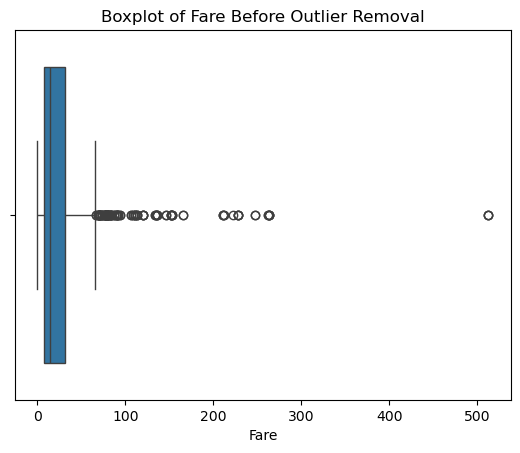

In [18]:
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare Before Outlier Removal")
plt.show()

In [19]:
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

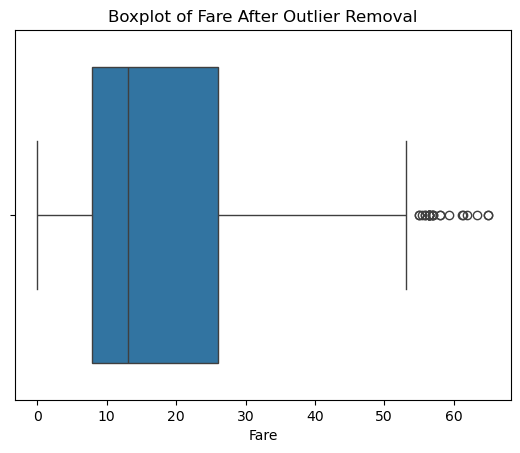

In [20]:
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare After Outlier Removal")
plt.show()

Outliers in the Fare column were detected using the Interquartile Range (IQR) method. Any values below the lower bound or above the upper bound were considered outliers.
These outliers were removed to reduce their effect on the analysis and improve data quality.

# Task 4
Normalize Numerical Features using Min-Max and Z-score

Select numerical features

In [21]:
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

1. Min-Max Normalization

In [22]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_features] = minmax_scaler.fit_transform(df[numerical_features])

df_minmax[numerical_features].head()

,Age,Fare,SibSp,Parch,Pclass
0,0.271174,0.111538,0.2,0.0,1.0
2,0.321438,0.121923,0.0,0.0,1.0
3,0.434531,0.816923,0.2,0.0,0.0
4,0.434531,0.123846,0.0,0.0,1.0
5,0.367921,0.130128,0.0,0.0,1.0


2. Z-score Standardization

In [23]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[numerical_features] = zscore_scaler.fit_transform(df[numerical_features])

df_zscore[numerical_features].head()

,Age,Fare,SibSp,Parch,Pclass
0,-0.556219,-0.779117,0.625606,-0.433718,0.708528
2,-0.243027,-0.729373,-0.486423,-0.433718,0.708528
3,0.461654,2.599828,0.625606,-0.433718,-2.016580
4,0.461654,-0.720161,-0.486423,-0.433718,0.708528
5,0.046606,-0.690071,-0.486423,-0.433718,0.708528


Two normalization techniques were applied to the numerical features.
Min-Max normalization was used to scale the values between 0 and 1. Z-score standardization was also applied to transform the data to have a mean of 0 and a standard deviation of 1. 
These methods help prepare the data for machine learning algorithms and improve comparability between features.

# Task 5
Apply PCA only if the numerical features show correlation

In [24]:
corr_matrix = df[numerical_features].corr()
corr_matrix

,Age,Fare,SibSp,Parch,Pclass
Age,1.000000,0.078863,-0.340947,-0.212343,-0.342826
Fare,0.078863,1.000000,0.370388,0.336844,-0.589776
SibSp,-0.340947,0.370388,1.000000,0.410182,0.113943
Parch,-0.212343,0.336844,0.410182,1.000000,0.083451
Pclass,-0.342826,-0.589776,0.113943,0.083451,1.000000


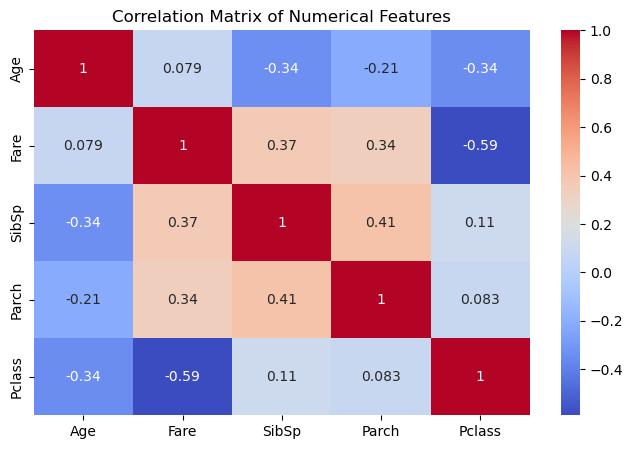

In [25]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

The correlation matrix is used to check whether the numerical features are correlated. Since some numerical features show correlation, PCA can be applied to reduce dimensionality and remove redundancy while preserving most of the important information.

# Apply PCA

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore[numerical_features])

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,-0.231225,1.192364
1,-0.932806,0.781531
2,1.650095,-2.726315
3,-1.114788,0.410823
4,-0.988726,0.613034


In [28]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.37060689 0.34129992]


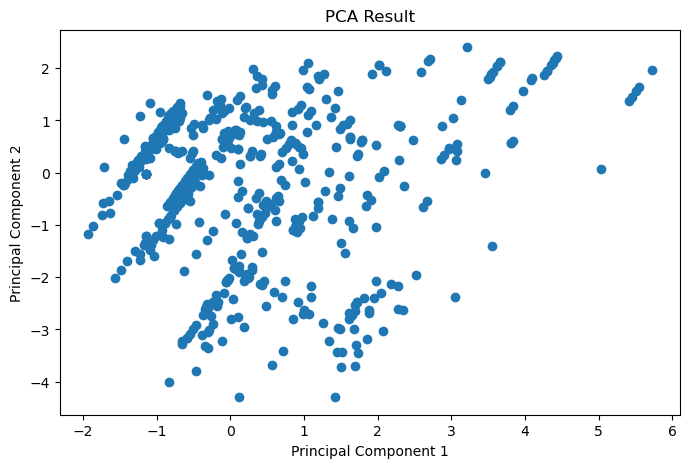

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA Result")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

PCA was applied because the numerical features showed correlation. The original numerical features were transformed into two principal components. This reduces the dimensionality of the dataset while preserving most of the important variance in the data.